# Verify Trial Structure
Split out from `03_psth_raster_NWB_testing.ipynb`. This notebook keeps the trial and event timing checks together.

In [1]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
%load_ext autoreload
%autoreload 2

import load_nwb
from load_nwb import nwb_loader
import nwb_data_prep as nwb_prep
import pca_data_prep as prep
import prep_data as data_prep
import PSTH_raster as psth_raster
import verify_data as verify

prep = importlib.reload(prep)
nwb_prep = importlib.reload(nwb_prep)
data_prep = importlib.reload(data_prep)
psth_raster = importlib.reload(psth_raster)
verify = importlib.reload(verify)

## Load Session From `.env`

In [2]:
session_data_dic = prep.load_env()
session_data_dic

MOUSE loaded: Reach15




-- Behavioral Files --
BEHAVIORAL_FOLDER loaded: grant_reach15_swingDoor-christie
-- First Neuropixels File --
NP_FILE loaded: Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01
NWB_FILE loaded: Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01
DATE loaded: 20260129
SESSION loaded: session003
BOMBCELL loaded: bombcell_batch_20260305_1130
PROBE_A_CH_CONFIG loaded: probeA_SIM_IP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json
PROBE_C_CH_CONFIG loaded: probeC_MoP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json
PROBE_D_CH_CONFIG loaded: probeD_VaL__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json


-- Second Neuropixels File --
NP_FILE loaded: Reach15_20260129_session004_NP_Recording_02_2026-01-29_16-50-32
NWB_FILE loaded: NA
DATE_01 loaded: 20260129
SESSION_01 loaded: session004
BOMBCELL_01 loaded: NA
PROBE_A_CH_CONFIG_01 loaded: NA
PROBE_C_CH_CONFIG_01 loaded: NA
PROBE_D_CH_CONFIG_01 loa

{'MOUSE': 'Reach15',
 'BEHAVIORAL_FOLDER': 'grant_reach15_swingDoor-christie',
 'NP_FILE': 'Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01',
 'DATE': '20260129',
 'SESSION': 'session003',
 'BOMBCELL': 'bombcell_batch_20260305_1130',
 'NWB_FILE': 'Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01',
 'PROBE_A_CH_CONFIG': 'probeA_SIM_IP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json',
 'PROBE_C_CH_CONFIG': 'probeC_MoP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json',
 'PROBE_D_CH_CONFIG': 'probeD_VaL__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json',
 'NP_FILE_01': 'Reach15_20260129_session004_NP_Recording_02_2026-01-29_16-50-32',
 'DATE_01': '20260129',
 'SESSION_01': 'session004',
 'BOMBCELL_01': 'NA',
 'NWB_FILE_01': 'NA',
 'PROBE_A_CH_CONFIG_01': 'NA',
 'PROBE_C_CH_CONFIG_01': 'NA',
 'PROBE_D_CH_CONFIG_01': 'NA',
 'NP_FILE_02': 'Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00',
 'DA

In [3]:
SESSION_TO_ANALYZE = 3

MOUSE, BEHAVIORAL_FOLDER, PROBE_A_CH_CONFIG, PROBE_C_CH_CONFIG, PROBE_D_CH_CONFIG, NP_FILE, NWB_FILE, DATE, SESSION, BOMBCELL = prep.session_to_analyze(
    session_data_dic['MOUSE'],
    session_data_dic['BEHAVIORAL_FOLDER'],
    session_data_dic['NP_FILE'],
    session_data_dic['NWB_FILE'],
    session_data_dic['DATE'],
    session_data_dic['SESSION'],
    session_data_dic['BOMBCELL'],
    session_data_dic['PROBE_A_CH_CONFIG'],
    session_data_dic['PROBE_C_CH_CONFIG'],
    session_data_dic['PROBE_D_CH_CONFIG'],
    session_data_dic['NP_FILE_01'],
    session_data_dic['NWB_FILE_01'],
    session_data_dic['DATE_01'],
    session_data_dic['SESSION_01'],
    session_data_dic['BOMBCELL_01'],
    session_data_dic['PROBE_A_CH_CONFIG_01'],
    session_data_dic['PROBE_C_CH_CONFIG_01'],
    session_data_dic['PROBE_D_CH_CONFIG_01'],
    session_data_dic['NP_FILE_02'],
    session_data_dic['NWB_FILE_02'],
    session_data_dic['DATE_02'],
    session_data_dic['SESSION_02'],
    session_data_dic['BOMBCELL_02'],
    session_data_dic['PROBE_A_CH_CONFIG_02'],
    session_data_dic['PROBE_C_CH_CONFIG_02'],
    session_data_dic['PROBE_D_CH_CONFIG_02'],
    session_selection=SESSION_TO_ANALYZE,
)

PROBES = ['A', 'B', 'C', 'D', 'E', 'F']
paths_dic = prep.setup_paths_and_verify(PROBES, NWB_FILE, NP_FILE, DATE, SESSION, BEHAVIORAL_FOLDER, BOMBCELL)
paths_dic


SESSION SELECTION:

NP_FILE: Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00
NWB_FILE: Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00
DATE: 20260201
SESSION: session007
BEHAVIORAL_FOLDER: grant_reach15_swingDoor-christie
BOMBCELL: bombcell_batch_20260304_1536
PROBE_A_CH_CONFIG: probeA_SIM_IP__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json
PROBE_C_CH_CONFIG: probeC_MoP__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json
PROBE_D_CH_CONFIG: probeD_VaL__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json
✅ Found bombcell data for probe A at H:\Grant\Neuropixel_Analysis\BOMBCELL\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell_batch_20260304_1536\kilosort4_A
✅ Found bombcell data for probe B at H:\Grant\Neuropixel_Analysis\BOMBCELL\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell_batch_20260304_1536\kilosort4_B
✅

{'NP_ROOT_DIR': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00'),
 'NWB_PATH': WindowsPath('H:/Grant/Neuropixel_Analysis/NWB/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00'),
 'BOMBCELL_ROOT_FOR_AUTO_BUILD': WindowsPath('H:/Grant/Neuropixel_Analysis/BOMBCELL/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/bombcell_batch_20260304_1536'),
 'baseline_trials_index_path': 'G:\\Grant\\behavior_data\\DLC_net\\grant_reach15_swingDoor-christie\\videos\\20260201\\christielab\\session007\\20260201_christielab_session007_baseline_trial_numbers_tone2_aligned.npy',
 'washout_trials_index_path': 'G:\\Grant\\behavior_data\\DLC_net\\grant_reach15_swingDoor-christie\\videos\\20260201\\christielab\\session007\\20260201_christielab_session007_washout_trial_numbers_tone2_aligned.npy',
 'optoicalStim_trials_index_path': 'G:\\Grant\\behavior_data\\DLC_net\\grant_reach15_swingDoor-christie

## Load NWB, Processed Bundle, and Event Arrays

In [4]:
mouse_nwb = paths_dic['NWB_PATH']
baseline_trials_index_path = paths_dic['baseline_trials_index_path']
washout_trials_index_path = paths_dic['washout_trials_index_path']
optoicalStim_trials_index_path = paths_dic['optoicalStim_trials_index_path']
BOMBCELL_ROOT_FOR_AUTO_BUILD = paths_dic['BOMBCELL_ROOT_FOR_AUTO_BUILD']

mouse_id = load_nwb.nwb_loader(mouse_nwb)
df_stim, df_units = nwb_loader.verify_nwb_data(mouse_id)

PROCESSED_BUNDLE_SESSION_DIR = Path.cwd().resolve() / 'processed_data' / NP_FILE
PROCESSED_BUNDLE_SESSION_DIR.mkdir(parents=True, exist_ok=True)

bundle, merged_dic, stim_df, df_stim, pca_event_meta_bundle, extras, meta, PROCESSED_BUNDLE_DIR = nwb_prep.load_or_build_processed_bundle(
    processed_bundle_dir=PROCESSED_BUNDLE_SESSION_DIR,
    nwb_path_for_auto_build=mouse_nwb,
    bombcell_root_for_auto_build=BOMBCELL_ROOT_FOR_AUTO_BUILD,
    use_bombcell_if_available=True,
    auto_build_bundle_if_missing=True,
    auto_rebuild_if_bombcell_missing=True,
    required_filenames=('merged_dic.pkl', 'stim_df.pkl', 'pca_event_meta.pkl'),
    verbose=True,
)

baseline_trials_idx = np.load(baseline_trials_index_path, allow_pickle=True)
washout_trials_idx = np.load(washout_trials_index_path, allow_pickle=True)
optoicalStim_trials_idx = np.load(optoicalStim_trials_index_path, allow_pickle=True)

tone1_start_times, tone2_start_times, frame_events_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times = data_prep.extract_start_times(df_stim)
(
    total_optical_timestamps,
    total_optoTagging_timestamps,
    total_opto_tagging_events,
    total_opto_tagging_pulses,
    first_opto_tagging_timestamp,
    end_opto_tagging_index,
    last_tone2_time,
    start_of_opto_tagging_index,
    behavioral_video_duration,
    final_behavioral_video_time,
    opto_closed_loop_start_timestamps,
    opto_tag_start_timestamps,
    last_closed_loop_start_time,
    first_opto_tagging_timestamp_per_trial,
    first_optical_pulse_per_closed_loop,
) = data_prep.seperate_closedLoop_optoTagging(
    optical_start_times,
    tone2_start_times,
    frame_events_start_times,
    total_opto_tagging_events=60,
    pulses_per_event=10,
)

pca_event_meta, tone1_start_times, tone2_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times, baseline_reachInit_stimROI_start_times, stimulation_reachInit_stimROI_start_times, washout_reachInit_stimROI_start_times = prep.build_pca_event_meta_and_event_times(
    stim_df=stim_df,
    baseline_trials_idx=baseline_trials_idx,
    optoicalStim_trials_idx=optoicalStim_trials_idx,
    washout_trials_idx=washout_trials_idx,
)

EVENT_TIME_ALIGN_TO = 'all_stimROI_triggers_start_times'
pca_event_meta_aligned, EVENT_TIME_ALIGN_REPORT = prep.align_pca_event_meta_start_times(
    pca_event_meta=pca_event_meta,
    align_to=EVENT_TIME_ALIGN_TO,
    tone1_start_times=tone1_start_times,
    tone2_start_times=tone2_start_times,
    stimROI_start_times=stimROI_start_times,
    optical_start_times=optical_start_times,
    all_stimROI_triggers_start_times=all_stimROI_triggers_start_times,
    baseline_reachInit_stimROI_start_times=baseline_reachInit_stimROI_start_times,
    stimulation_reachInit_stimROI_start_times=stimulation_reachInit_stimROI_start_times,
    washout_reachInit_stimROI_start_times=washout_reachInit_stimROI_start_times,
    custom_event_start_times=None,
    mismatch='index_then_nearest',
    max_delta_s=None,
    drop_unmatched=True,
)

output_root = Path(r'H:\Grant\Neuropixel_Analysis\TRIAL_STRUCTURE') / str(NP_FILE)

loaded NWB from: H:\Grant\Neuropixel_Analysis\NWB\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00

===== Total units Per Probe ====
A:  554
B:  1316
C:  355
D:  820
E:  864
F:  691

 ======= Unique stimulus types ==========   : 
 ['tone1_timestamps' 'tone2_timestamps' 'stimROI_timestamps'
 'frame_events_timestamp' 'optical_timestamps'
 'reachInit_stimROI_timestamps' 'opto_tagging_timestamps'
 'baseline_reachInit_stimROI_timestamps'
 'stimulation_reachInit_stimROI_timestamps'
 'washout_reachInit_stimROI_timestamps']

===== Total Timestamps Per Event ====
tone1_timestamps:  376
tone2_timestamps:  270
stimROI_timestamps:  130
frame_events_timestamp:  1349818
optical_timestamps:  1900
reachInit_stimROI_timestamps:  270
opto_tagging_timestamps:  60
baseline_reachInit_stimROI_timestamps:  20
stimulation_reachInit_stimROI_timestamps:  130
washout_reachInit_stimROI_timestamps:  120


Loaded bundle: C:\Users\user\Documents\github\NWB_and_Reaching_analysis\mice\Reach15\anal

#### All plots will be saved here

In [5]:
output_root

WindowsPath('H:/Grant/Neuropixel_Analysis/TRIAL_STRUCTURE/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00')

## Core Verification Checks

In [6]:
verify_result = verify.verify_task_epoch_structure(
    baseline_trials_idx,
    optoicalStim_trials_idx,
    washout_trials_idx,
    trials_per_epoch=20,
    show_plot=False,
    verbose=True,
)
stim_timing_dic = verify.check_stim_event_timing(df_stim, max_window=4, show_detailed_output=True)
verify_result

Total Baseline Trials:  20
Total Washout epochs:  5
Total Optical Stim epochs:  5

baseline_trials_idx [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
optoicalStim_trials_idx [list([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])
 list([61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80])
 list([101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120])
 list([141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160])
 list([181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270])]
washout_trials_idx [list([41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60])
 list([81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92

{'ok': False,
 'errors': ['Stim epoch 7 size = 10 (expected 20).'],
 'warnings': ['Stim epochs (7) != Wash epochs (6); checking first 6 pairs.'],
 'used_epochs': {'baseline': array([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
          19, 20]], dtype=object),
  'stim': array([list([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]),
         list([61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]),
         list([101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]),
         list([141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160]),
         list([181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200]),
         list([221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240]),
         list([261, 262, 263, 264, 265, 266, 267,

Saved trial structure plot to: H:\Grant\Neuropixel_Analysis\TRIAL_STRUCTURE\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\epoch_structure\expected_epoch_structure.png


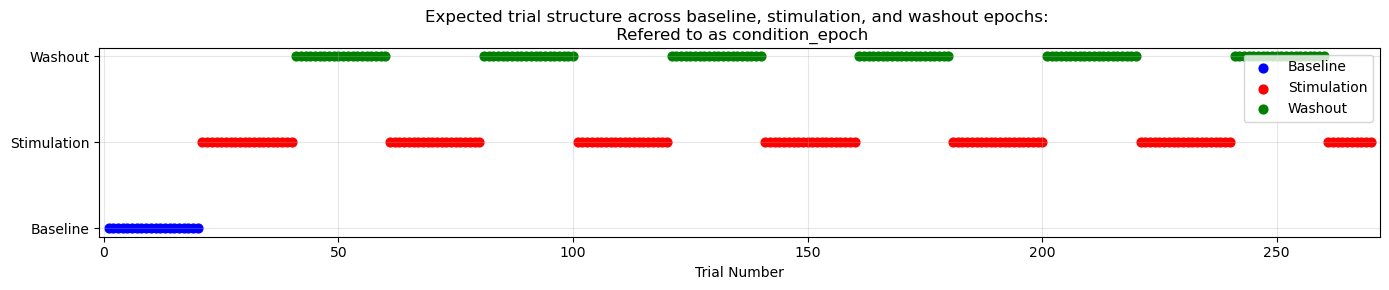

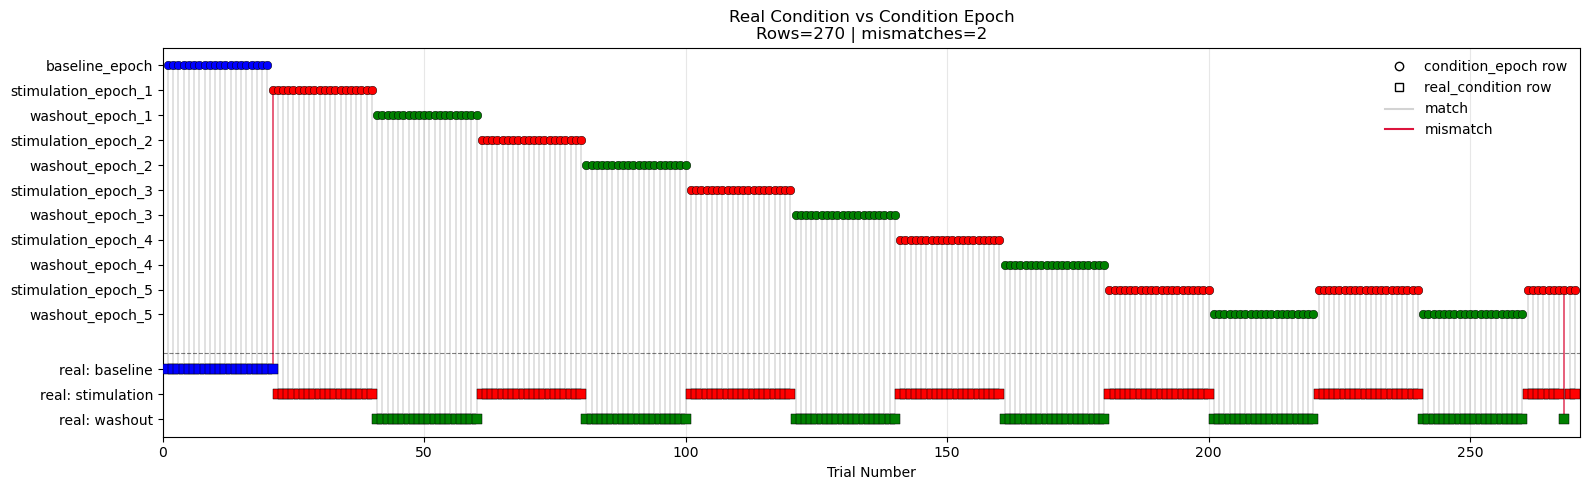

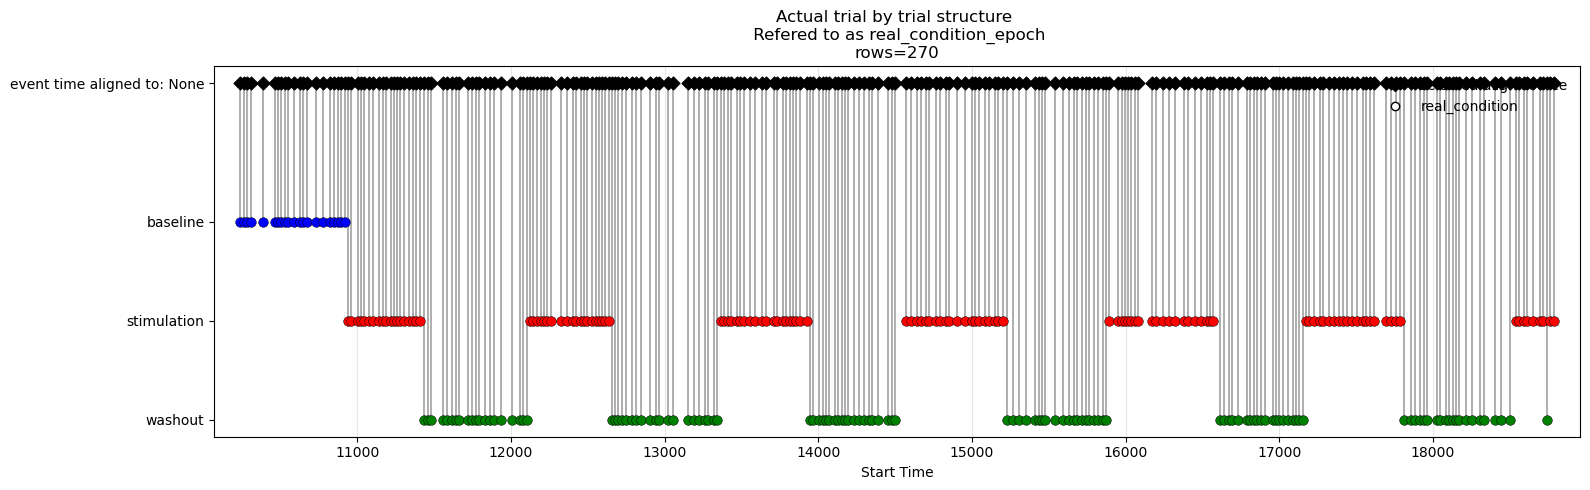

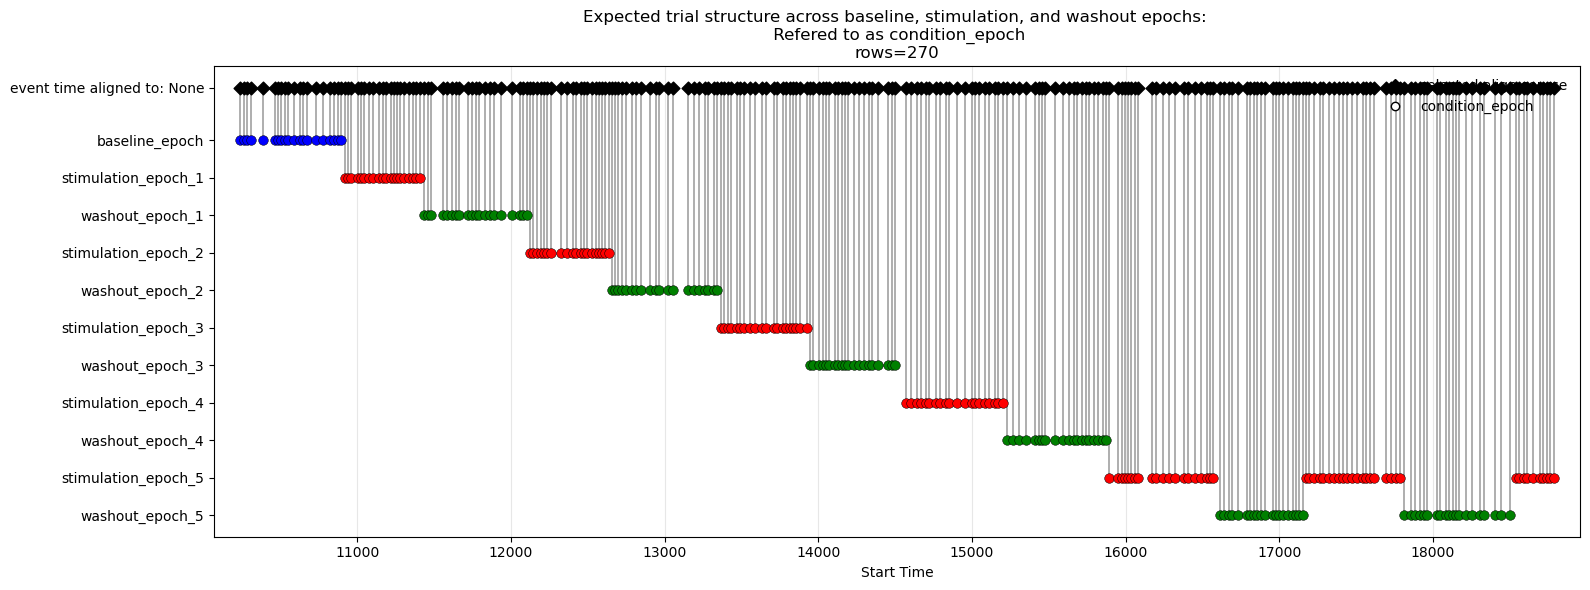

In [7]:
verify.plot_task_epoch_structure(
    baseline_trials_idx,
    optoicalStim_trials_idx,
    washout_trials_idx,
    trials_are_one_based=True,
    figsize=(14, 3),
    save_plot_path=output_root /'epoch_structure' / 'expected_epoch_structure.png',
)

verify.plot_real_condition_vs_condition_epoch(
    pca_event_meta_aligned,
    figsize=(16, 5),
    save_plot_path=output_root /'epoch_structure' / 'real_condition_vs_condition_epoch.png',
)
verify.plot_event_time_align_to_vs_real_condition(
    pca_event_meta_aligned,
    align_to=EVENT_TIME_ALIGN_TO,
    figsize=(16, 5),
    save_plot_path=output_root /'epoch_structure' / 'event_time_align_to_vs_real_condition.png',
)
verify.plot_event_time_align_to_vs_condition_epoch(
    pca_event_meta_aligned,
    align_to=EVENT_TIME_ALIGN_TO,
    figsize=(16, 6),
    save_plot_path=output_root/ 'epoch_structure' / 'event_time_align_to_vs_condition_epoch.png',
)

## Reach-Init Structure Checks

In [8]:
reach_Init_from_StimROI_with_STIM = stimulation_reachInit_stimROI_start_times
reach_Init_from_StimROI_without_STIM = washout_reachInit_stimROI_start_times
reach_Init_baseline = baseline_reachInit_stimROI_start_times
all_reach_Init_from_StimROI = np.concatenate([
    reach_Init_baseline,
    reach_Init_from_StimROI_with_STIM,
    reach_Init_from_StimROI_without_STIM,
])
all_reach_Init_from_StimROI = np.sort(all_reach_Init_from_StimROI)

print('total reach_Init_baseline:', len(reach_Init_baseline))
print('total reach_Init_from_StimROI_with_STIM:', len(reach_Init_from_StimROI_with_STIM))
print('total reach_Init_from_StimROI_without_STIM:', len(reach_Init_from_StimROI_without_STIM))
print('total all_reach_Init_from_StimROI:', len(all_reach_Init_from_StimROI))

merged_reach_init = np.concatenate([
    baseline_reachInit_stimROI_start_times,
    stimulation_reachInit_stimROI_start_times,
    washout_reachInit_stimROI_start_times,
])
merged_reach_init = np.sort(merged_reach_init)

print('stim vs stimROI exact matches:', np.sum(stimulation_reachInit_stimROI_start_times == stimROI_start_times[:len(stimulation_reachInit_stimROI_start_times)]))
print('all reachInit vs merged exact matches:', np.sum(all_stimROI_triggers_start_times == merged_reach_init[:len(all_stimROI_triggers_start_times)]))

total reach_Init_baseline: 20
total reach_Init_from_StimROI_with_STIM: 130
total reach_Init_from_StimROI_without_STIM: 120
total all_reach_Init_from_StimROI: 270
stim vs stimROI exact matches: 130
all reachInit vs merged exact matches: 0


## Optical Event Sanity Check

In [9]:
len(opto_closed_loop_start_timestamps)

1300

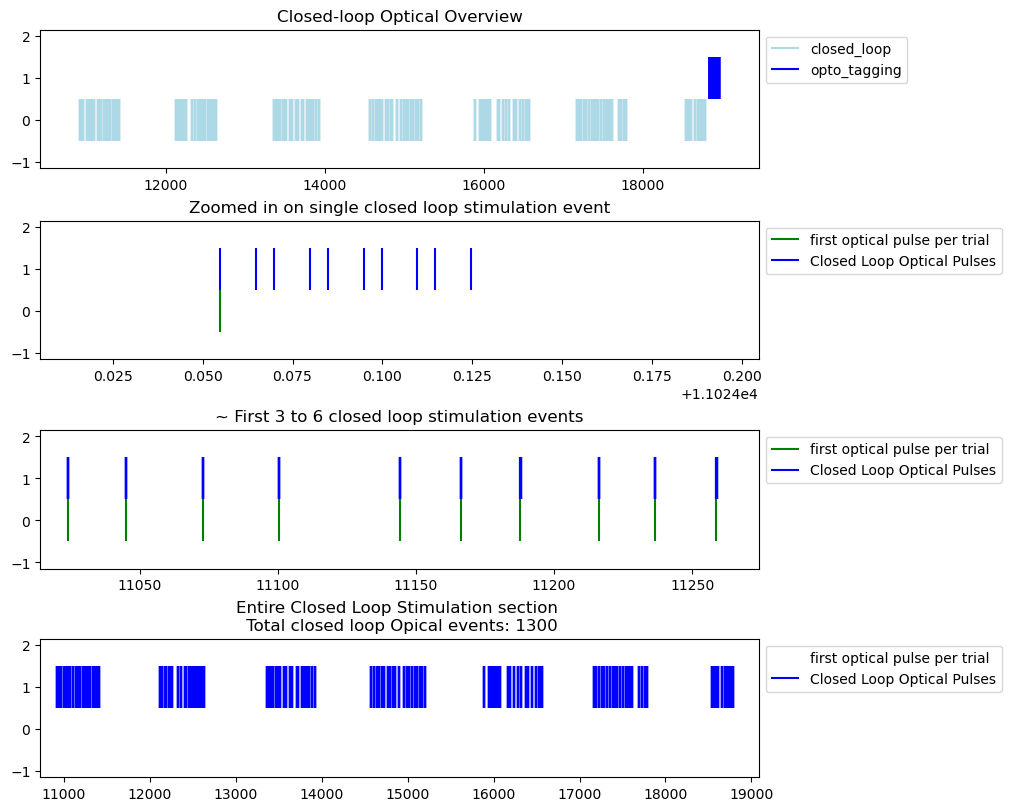

In [20]:
def plot_closedLoop_optical_events(save_plots=None):
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), constrained_layout=True)

    axes[0].eventplot([opto_closed_loop_start_timestamps, opto_tag_start_timestamps], orientation='horizontal', colors=['lightblue', 'b'])
    axes[0].set_xlim(opto_closed_loop_start_timestamps[0] - 500, opto_tag_start_timestamps[-1] + 500)
    axes[0].set_title('Closed-loop Optical Overview')
    axes[0].legend(['closed_loop', 'opto_tagging'], loc='upper left', bbox_to_anchor=(1, 1))

    single_idx = min(40, len(opto_closed_loop_start_timestamps) - 1)
    axes[1].eventplot([first_optical_pulse_per_closed_loop, opto_closed_loop_start_timestamps], orientation='horizontal', colors=['g', 'b'])
    axes[1].set_xlim(opto_closed_loop_start_timestamps[single_idx] - 0.05, opto_closed_loop_start_timestamps[single_idx] + 0.15)
    axes[1].set_title('Zoomed in on single closed loop stimulation event')
    axes[1].legend(['first optical pulse per trial', 'Closed Loop Optical Pulses'], loc='upper left', bbox_to_anchor=(1, 1))


    single_idx = min(40, len(opto_closed_loop_start_timestamps) - 1)
    axes[2].eventplot([first_optical_pulse_per_closed_loop, opto_closed_loop_start_timestamps], orientation='horizontal', colors=['g', 'b'])
    axes[2].set_xlim(opto_closed_loop_start_timestamps[single_idx] - 10, opto_closed_loop_start_timestamps[single_idx] + 250)
    axes[2].set_title('~ First 3 to 6 closed loop stimulation events')
    axes[2].legend(['first optical pulse per trial', 'Closed Loop Optical Pulses'], loc='upper left', bbox_to_anchor=(1, 1))
    
    single_idx = min(40, len(opto_closed_loop_start_timestamps) - 1)
    axes[3].eventplot([first_optical_pulse_per_closed_loop, opto_closed_loop_start_timestamps], orientation='horizontal', colors=['w', 'b'])
    axes[3].set_xlim(opto_closed_loop_start_timestamps[single_idx] - 300, opto_closed_loop_start_timestamps[-1] + 300)
    axes[3].set_title(f'Entire Closed Loop Stimulation section \n Total closed loop Opical events: {len(opto_closed_loop_start_timestamps)}')
    axes[3].legend(['first optical pulse per trial', 'Closed Loop Optical Pulses'], loc='upper left', bbox_to_anchor=(1, 1))

    save_path = output_root / 'optical_events' / f'closed_loop.png'
    if save_path is not None:
        if save_path.parent is not None:
                save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()

plot_closedLoop_optical_events(save_plots=None)


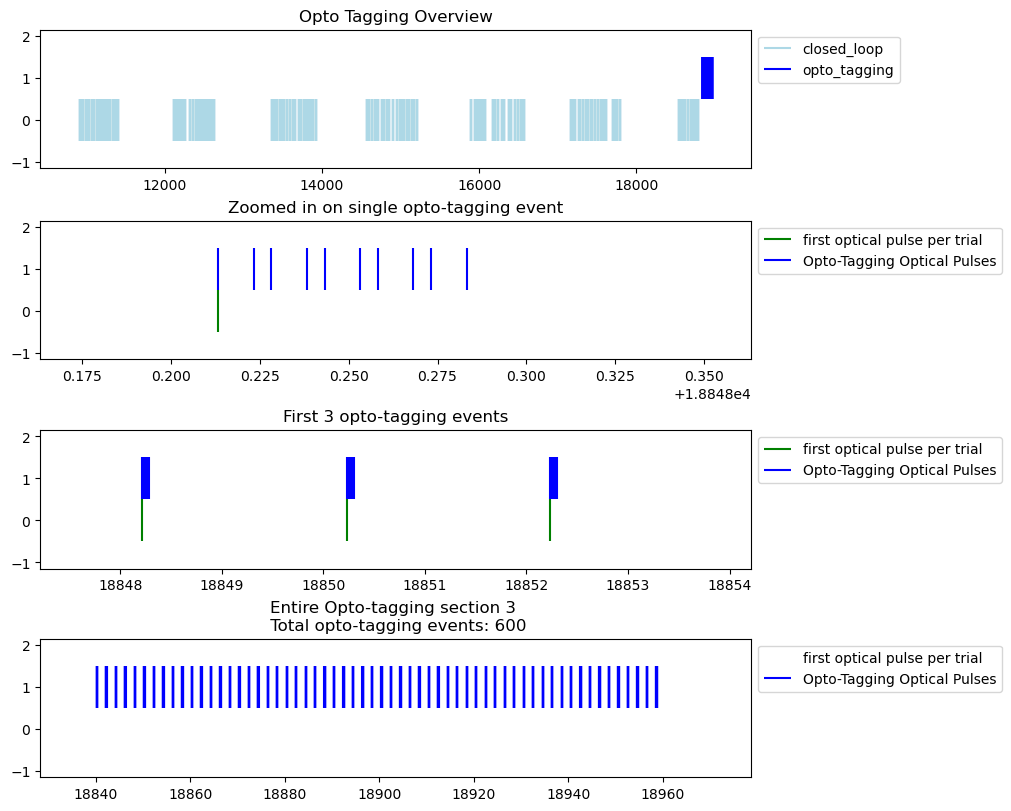

In [22]:

def plot_optical_events(save_plots=None):
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), constrained_layout=True)

    axes[0].eventplot([opto_closed_loop_start_timestamps, opto_tag_start_timestamps], orientation='horizontal', colors=['lightblue', 'b'])
    axes[0].set_xlim(opto_closed_loop_start_timestamps[0] - 500, opto_tag_start_timestamps[-1] + 500)
    axes[0].set_title('Opto Tagging Overview')
    axes[0].legend(['closed_loop', 'opto_tagging'], loc='upper left', bbox_to_anchor=(1, 1))

    single_idx = min(40, len(opto_tag_start_timestamps) - 1)
    axes[1].eventplot([first_opto_tagging_timestamp_per_trial, opto_tag_start_timestamps], orientation='horizontal', colors=['g', 'b'])
    axes[1].set_xlim(opto_tag_start_timestamps[single_idx] - 0.05, opto_tag_start_timestamps[single_idx] + 0.15)
    axes[1].set_title('Zoomed in on single opto-tagging event')
    axes[1].legend(['first optical pulse per trial', 'Opto-Tagging Optical Pulses'], loc='upper left', bbox_to_anchor=(1, 1))


    single_idx = min(40, len(opto_tag_start_timestamps) - 1)
    axes[2].eventplot([first_opto_tagging_timestamp_per_trial, opto_tag_start_timestamps], orientation='horizontal', colors=['g', 'b'])
    axes[2].set_xlim(opto_tag_start_timestamps[single_idx] - 1, opto_tag_start_timestamps[single_idx] + 6)
    axes[2].set_title('First 3 opto-tagging events')
    axes[2].legend(['first optical pulse per trial', 'Opto-Tagging Optical Pulses'], loc='upper left', bbox_to_anchor=(1, 1))
    
    single_idx = min(40, len(opto_tag_start_timestamps) - 1)
    axes[3].eventplot([first_opto_tagging_timestamp_per_trial, opto_tag_start_timestamps], orientation='horizontal', colors=['w', 'b'])
    axes[3].set_xlim(opto_tag_start_timestamps[single_idx] - 20, opto_tag_start_timestamps[-1] + 20)
    axes[3].set_title('Entire Opto-tagging section 3 \n Total opto-tagging events: ' + str(len(opto_tag_start_timestamps)))
    axes[3].legend(['first optical pulse per trial', 'Opto-Tagging Optical Pulses'], loc='upper left', bbox_to_anchor=(1, 1))

    save_path = output_root / 'optical_events' / f'opto_tagging.png'
    if save_path is not None:
        if save_path.parent is not None:
                save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()

plot_optical_events()

## Trial Events Sanity Checks

In [12]:

def plot_event_times_around_tone2(reach_number):
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), constrained_layout=True)

    print(f"Plotting event times around tone2 for reach number: {reach_number}")
    axes[0].eventplot(
        [tone1_start_times, tone2_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times],
        orientation='horizontal',
        colors=['r', 'green', 'purple', 'b', 'orange'],
        linelengths=0.9,
    )
    axes[0].set_xlim(tone2_start_times[reach_number] - 4, tone2_start_times[reach_number] + 4)
    axes[0].set_title('One trial window around tone2')
    axes[0].legend(['tone1', 'tone2', 'stimROI', 'optical', 'reachInit'], loc='upper left', bbox_to_anchor=(1, 1))

    axes[1].eventplot([opto_closed_loop_start_timestamps, opto_tag_start_timestamps], orientation='horizontal', colors=['g', 'b'])
    axes[1].set_xlim(opto_closed_loop_start_timestamps[0] - 500, opto_tag_start_timestamps[-1] + 500)
    axes[1].set_title('Closed-loop optical vs opto-tagging across recording')
    axes[1].legend(['closed_loop', 'opto_tagging'], loc='upper left', bbox_to_anchor=(1, 1))

    single_idx = min(40, len(opto_tag_start_timestamps) - 1)
    axes[2].eventplot([first_opto_tagging_timestamp_per_trial, opto_tag_start_timestamps], orientation='horizontal', colors=['g', 'b'])
    axes[2].set_xlim(opto_tag_start_timestamps[single_idx] - 0.05, opto_tag_start_timestamps[single_idx] + 0.25)
    axes[2].set_title('First opto-tag pulse per trial check')
    axes[2].legend(['first_per_trial', 'all_opto_tag_pulses'], loc='upper left', bbox_to_anchor=(1, 1))
    save_path = output_root / 'individual_trials' / f'event_times_around_tone2_reach_{reach_number}.png'
    if save_path is not None:
        if save_path.parent is not None:
                save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()



### Trial / Reach Number 19 
- Should Not have Stimulation

Plotting event times around tone2 for reach number: 19


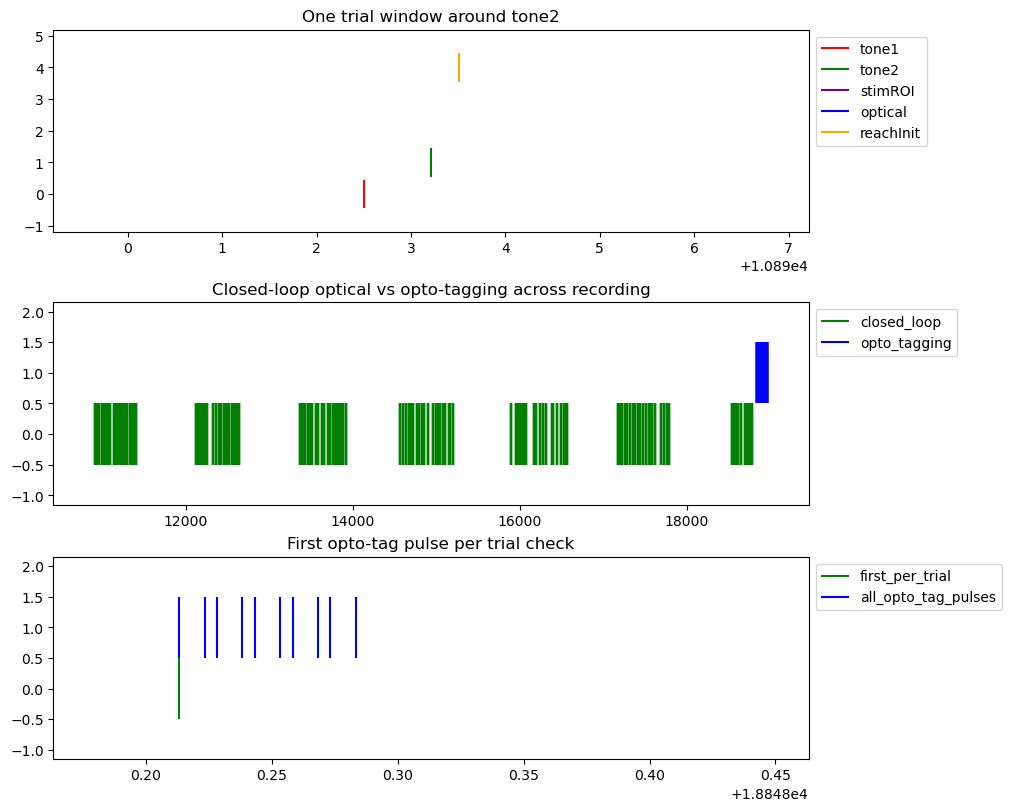

In [13]:
reach_number = 19
plot_event_times_around_tone2(reach_number)


### Trial / Reach Number #21 
- Should have stimulation

Plotting event times around tone2 for reach number: 21


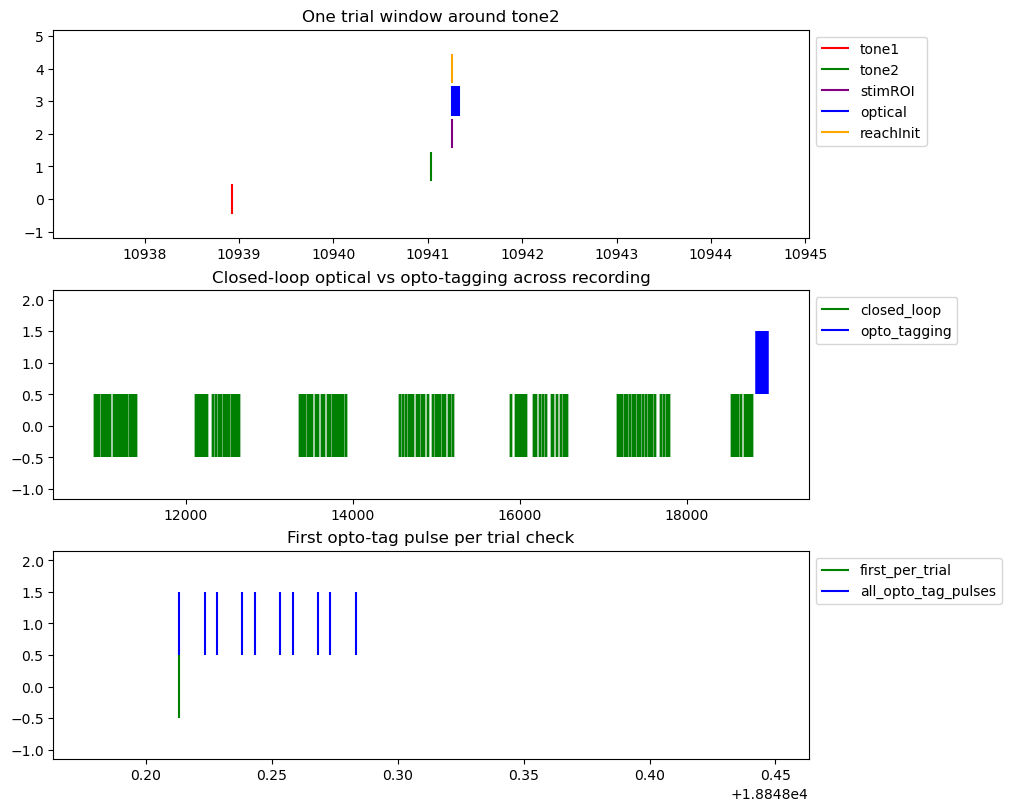

In [14]:
reach_number = 21
plot_event_times_around_tone2(reach_number)

### Batch look at all trials around tone2

In [44]:
def plot_event_times_around_tone2_individual_x(
    tone1_start_times,
    tone2_start_times,
    stimROI_start_times,
    optical_start_times,
    all_stimROI_triggers_start_times,
    output_root,
    window_half_width=2.75
):
    reach_numbers = np.arange(len(tone2_start_times))
    print(f"Total reaches: {len(reach_numbers)}")

    group_size = 20
    reach_number_groups = [
        reach_numbers[k:k + group_size]
        for k in range(0, len(reach_numbers), group_size)
    ]

    print(f"Total reach groups (20 reaches each): {len(reach_number_groups)}")

    for i, reach_group in enumerate(reach_number_groups):
        fig, axes = plt.subplots(10, 2, figsize=(15, 25), constrained_layout=True)
        axes = axes.flatten()

        for j, reach_number in enumerate(reach_group):
            x_axis_center = tone2_start_times[reach_number]
            x_min = x_axis_center - window_half_width
            x_max = x_axis_center + window_half_width

            # old code:
            # axes[j].eventplot(
            #     [tone1_start_times, tone2_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times],
            #     orientation='horizontal',
            #     colors=['r', 'green', 'purple', 'b', 'orange'],
            #     linelengths=0.9,
            #     linestyles='solid',
            #     linewidths=2,
            # )

            # New code: crop each event array to this reach's own window
            tone1_window = tone1_start_times[(tone1_start_times >= x_min) & (tone1_start_times <= x_max)]
            tone2_window = tone2_start_times[(tone2_start_times >= x_min) & (tone2_start_times <= x_max)]
            stimROI_window = stimROI_start_times[(stimROI_start_times >= x_min) & (stimROI_start_times <= x_max)]
            optical_window = optical_start_times[(optical_start_times >= x_min) & (optical_start_times <= x_max)]
            reachInit_window = all_stimROI_triggers_start_times[
                (all_stimROI_triggers_start_times >= x_min) & (all_stimROI_triggers_start_times <= x_max)
            ]

            print(f"individual_x | j: {j}, reach_number: {reach_number}, tone2_time: {tone2_start_times[reach_number]}")

            axes[j].eventplot(
                [tone1_window, tone2_window, stimROI_window, optical_window, reachInit_window],
                orientation='horizontal',
                colors=['r', 'green', 'purple', 'b', 'orange'],
                linelengths=0.9,
                linestyles='solid',
                linewidths=2,
            )

            axes[j].set_xlim(x_min, x_max)
            axes[j].set_title(f'Trial window around tone2 for reach {reach_number + 1}')

            if j == 0:
                axes[j].legend(
                    ['tone1', 'tone2', 'stimROI', 'optical', 'reachInit'],
                    loc='upper left',
                    bbox_to_anchor=(1, 1)
                )

        for j in range(len(reach_group), len(axes)):
            axes[j].set_visible(False)

        save_path = output_root / 'individual_trials' / 'individual_x_axis' / (
            f'event_times_around_tone2_reaches_{reach_group[0] + 1}_to_{reach_group[-1] + 1}_20_per_fig_individual_x.png'
        )

        if save_path.parent is not None:
            save_path.parent.mkdir(parents=True, exist_ok=True)

        plt.savefig(save_path, dpi=220, bbox_inches="tight")
        plt.close(fig)

plot_event_times_around_tone2_individual_x(
    tone1_start_times,
    tone2_start_times,
    stimROI_start_times,
    optical_start_times,
    all_stimROI_triggers_start_times,
    output_root,
    window_half_width=2.75
)

Total reaches: 270
Total reach groups (20 reaches each): 14
individual_x | j: 0, reach_number: 0, tone2_time: 10239.9446
individual_x | j: 1, reach_number: 1, tone2_time: 10263.386666666667
individual_x | j: 2, reach_number: 2, tone2_time: 10284.956566666666
individual_x | j: 3, reach_number: 3, tone2_time: 10305.7464
individual_x | j: 4, reach_number: 4, tone2_time: 10382.945233333334
individual_x | j: 5, reach_number: 5, tone2_time: 10462.508266666666
individual_x | j: 6, reach_number: 6, tone2_time: 10484.2232
individual_x | j: 7, reach_number: 7, tone2_time: 10504.381966666666
individual_x | j: 8, reach_number: 8, tone2_time: 10526.1049
individual_x | j: 9, reach_number: 9, tone2_time: 10546.6267
individual_x | j: 10, reach_number: 10, tone2_time: 10586.899266666667
individual_x | j: 11, reach_number: 11, tone2_time: 10626.9118
individual_x | j: 12, reach_number: 12, tone2_time: 10647.384633333333
individual_x | j: 13, reach_number: 13, tone2_time: 10675.073066666666
individual_x |

## plot_trials_by_epoch

In [15]:

def plot_trials_by_epoch(reach_number):
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

    print(f"Plotting event times around tone2 for reach number: {reach_number}")
    axes[0].eventplot(
        [tone1_start_times, tone2_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times],
        orientation='horizontal',
        colors=['r', 'green', 'purple', 'b', 'orange'],
        linelengths=0.9,
    )
    axes[0].set_xlim(tone2_start_times[reach_number] - 4, tone2_start_times[reach_number] + 4)
    axes[0].set_title('One trial window around tone2')
    axes[0].legend(['tone1', 'tone2', 'stimROI', 'optical', 'reachInit'], loc='upper left', bbox_to_anchor=(1, 1))

    axes[1].eventplot([opto_closed_loop_start_timestamps, opto_tag_start_timestamps], orientation='horizontal', colors=['g', 'b'])
    axes[1].set_xlim(opto_closed_loop_start_timestamps[0] - 500, opto_tag_start_timestamps[-1] + 500)
    axes[1].set_title('Closed-loop optical vs opto-tagging across recording')
    axes[1].legend(['closed_loop', 'opto_tagging'], loc='upper left', bbox_to_anchor=(1, 1))

    save_path = output_root / 'individual_trials' / f'event_times_around_tone2_reach_{reach_number}.png'
    if save_path is not None:
        if save_path.parent is not None:
                save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()



### Plot By ReachInit

Saving reach-init structure plot to: H:\Grant\Neuropixel_Analysis\TRIAL_STRUCTURE\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\reach_init_structure\reachInit_structure_across_epochs.png


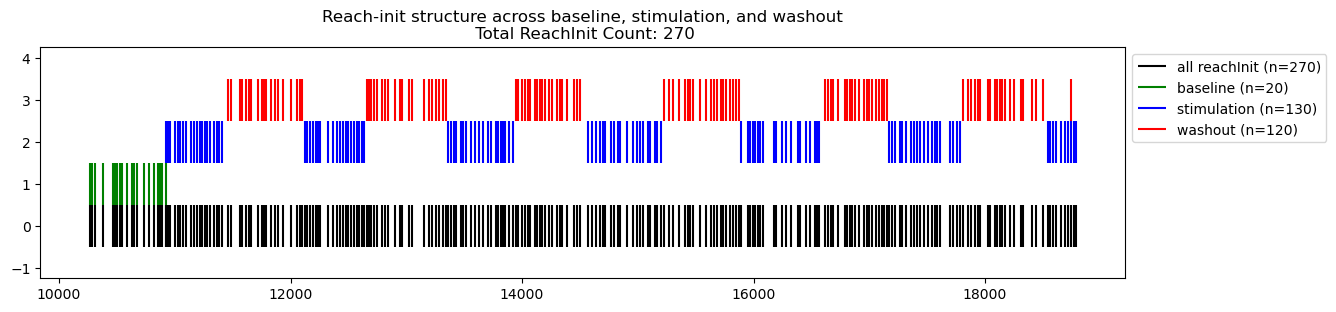

In [16]:
def reachInit_structure_across_epochs():
    plt.figure(figsize=(14, 3))
    plt.eventplot(
        [all_reach_Init_from_StimROI, reach_Init_baseline, reach_Init_from_StimROI_with_STIM, reach_Init_from_StimROI_without_STIM],
        orientation='horizontal',
        colors=['black', 'green', 'blue', 'red'],
    )
    plt.legend(['all reachInit (n={})'.format(len(all_reach_Init_from_StimROI)), 'baseline (n={})'.format(len(reach_Init_baseline)), 'stimulation (n={})'.format(len(reach_Init_from_StimROI_with_STIM)), 'washout (n={})'.format(len(reach_Init_from_StimROI_without_STIM))], loc='upper left', bbox_to_anchor=(1, 1))
    plt.title('Reach-init structure across baseline, stimulation, and washout\n Total ReachInit Count: {}'.format(len(all_reach_Init_from_StimROI)))
    save_path = output_root / 'reach_init_structure' / 'reachInit_structure_across_epochs.png'
    if save_path is not None:
        if save_path.parent is not None:
                save_path.parent.mkdir(parents=True, exist_ok=True)
        print(f"Saving reach-init structure plot to: {save_path}")
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()

reachInit_structure_across_epochs()